# HIRA Episode EDA — Sudogwon (Seoul + Incheon + Gyeonggi)

Pre-fit data inspection for the HIRA-based calibration variant.

- **Spatial**: Sudogwon (sido codes 11 + 28 + 41), summed.
- **Setting**: `outpatient_inpatient` (HIRA sheet 외래입원주부상병).
- **Season**: ISO W36 of start year → ISO W35 of next year (52 weeks).
- **Coverage**: 18 seasons, 2006-2007 .. 2023-2024.
- **Anomalous seasons**: `2009-2010` (H1N1pdm09 pandemic);
  `2020-2021`, `2021-2022`, `2022-2023` (COVID-19 era suppression / disruption).

Outputs are written to `outputs/eda/` (PNG + CSV).


In [1]:
# Cell 1 — Load HIRA episodes, weekly aggregate, per-season long-form DF
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from kt_data import (
    HIRA_AGE_GROUPS,
    SUDOGWON_SIDO_CODES,
    aggregate_hira_weekly,
    extract_hira_season,
    load_hira_episodes,
    load_population_15groups,
)
from kt_epimodel_hira.calibration.hira_target import HIRA_GROUP_TO_NIMS_WEIGHTED

warnings.filterwarnings("ignore", category=FutureWarning)

OUTDIR = Path("../outputs/eda")
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.unicode_minus": False,
    "font.family": "DejaVu Sans",
})

SEASONS = [f"{y}-{y+1}" for y in range(2006, 2024)]
PANDEMIC = {"2009-2010"}
COVID = {"2020-2021", "2021-2022", "2022-2023"}
ANOMALOUS = PANDEMIC | COVID

print(f"Seasons defined: {len(SEASONS)}  ({SEASONS[0]} .. {SEASONS[-1]})")
print(f"  Pandemic: {sorted(PANDEMIC)}")
print(f"  COVID:    {sorted(COVID)}")

df_daily = load_hira_episodes(
    setting="outpatient_inpatient",
    sido_codes=SUDOGWON_SIDO_CODES,
)
print(f"\nDaily long-form rows: {df_daily.height:,}")
print(f"Date range:           {df_daily['date'].min()} .. {df_daily['date'].max()}")
print(f"Total episodes:       {df_daily['episodes'].sum():,}")

df_weekly = aggregate_hira_weekly(df_daily, sum_over=("sido_code", "sex"))
print(f"Weekly rows:          {df_weekly.height:,}")

season_frames = []
for season in SEASONS:
    start_year = int(season.split("-")[0])
    sub = extract_hira_season(
        df_weekly, season_start_year=start_year,
        season_start_week=36, season_length_weeks=52,
    ).with_columns(pl.lit(season).alias("season"))
    season_frames.append(sub)

df_season = pl.concat(season_frames).with_columns(
    (pl.col("week_in_season") + 1).alias("week_in_season")  # 1-indexed for display
)
print(f"\nSeason long-form rows: {df_season.height:,}")

# Verification: 2019-2020 ISO sum vs date-range sum
v_iso = df_season.filter(pl.col("season") == "2019-2020")["episodes"].sum()
df_dr = load_hira_episodes(
    setting="outpatient_inpatient",
    sido_codes=SUDOGWON_SIDO_CODES,
    date_range=("2019-09-01", "2020-08-31"),
)
v_dr = df_dr["episodes"].sum()
print(f"\nVerification 2019-2020:")
print(f"  ISO W36..W35 sum:        {v_iso:,}")
print(f"  date_range 9/1..8/31:    {v_dr:,}  (expected 817,914)")
print(f"  delta:                    {v_dr - v_iso:+,}  (boundary days)")

df_season.head(8)


Seasons defined: 18  (2006-2007 .. 2023-2024)
  Pandemic: ['2009-2010']
  COVID:    ['2020-2021', '2021-2022', '2022-2023']

Daily long-form rows: 196,884
Date range:           2006-01-01 .. 2024-12-31
Total episodes:       11,718,844
Weekly rows:          5,958

Season long-form rows: 5,616

Verification 2019-2020:
  ISO W36..W35 sum:        817,879
  date_range 9/1..8/31:    817,914  (expected 817,914)
  delta:                    +35  (boundary days)


week_start_date,iso_year,iso_week,age_group,episodes,week_in_season,season
date,i32,i8,str,i64,i32,str
2006-09-04,2006,36,"""0-5""",238,1,"""2006-2007"""
2006-09-04,2006,36,"""12-17""",83,1,"""2006-2007"""
2006-09-04,2006,36,"""18-44""",454,1,"""2006-2007"""
2006-09-04,2006,36,"""45-64""",396,1,"""2006-2007"""
2006-09-04,2006,36,"""6-11""",142,1,"""2006-2007"""
2006-09-04,2006,36,"""65+""",767,1,"""2006-2007"""
2006-09-11,2006,37,"""0-5""",154,2,"""2006-2007"""
2006-09-11,2006,37,"""12-17""",97,2,"""2006-2007"""


saved ../outputs/eda/01_seasons_overview.png


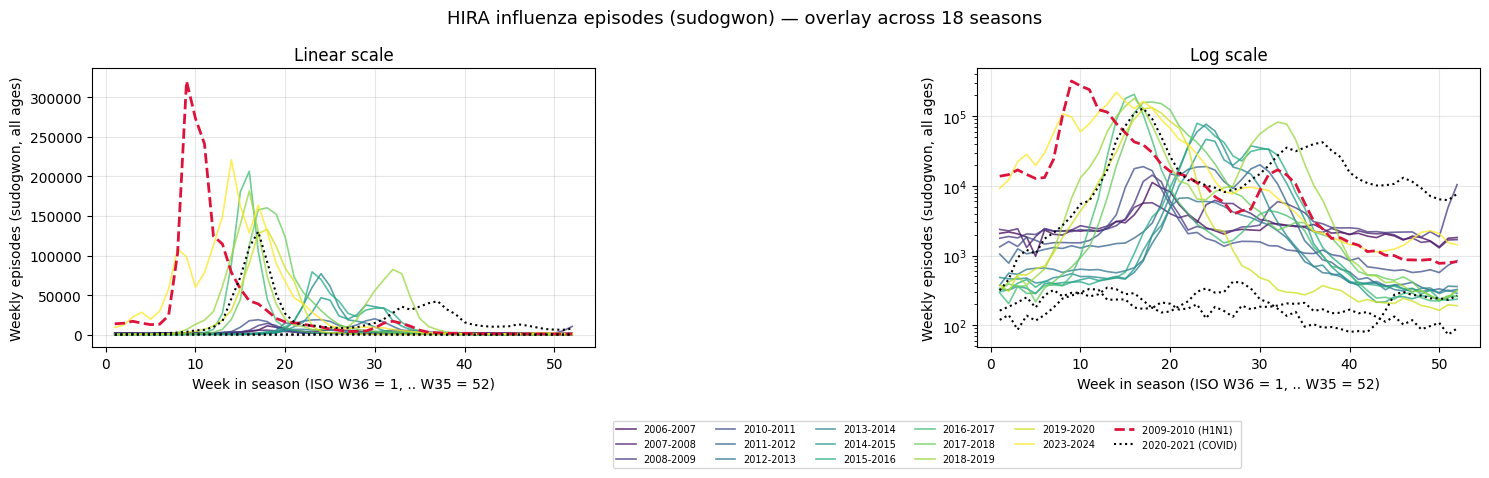

In [2]:
# Cell 2 — Seasons overview (all ages summed)
df_total = (
    df_season.group_by(["season", "week_in_season"])
    .agg(pl.col("episodes").sum())
    .sort(["season", "week_in_season"])
    .to_pandas()
)

cmap = mpl.colormaps["viridis"]
normal_seasons = [s for s in SEASONS if s not in ANOMALOUS]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, ylog in zip(axes, [False, True]):
    for i, s in enumerate(normal_seasons):
        sub = df_total[df_total["season"] == s]
        color = cmap(i / max(1, len(normal_seasons) - 1))
        ax.plot(sub["week_in_season"], sub["episodes"],
                color=color, alpha=0.75, lw=1.2, label=s)
    for s in sorted(PANDEMIC):
        sub = df_total[df_total["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color="crimson", linestyle="--", lw=2.0, label=f"{s} (H1N1)")
    for s in sorted(COVID):
        sub = df_total[df_total["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color="black", linestyle=":", lw=1.5,
                label=f"{s} (COVID)" if s == "2020-2021" else None)
    ax.set_xlabel("Week in season (ISO W36 = 1, .. W35 = 52)")
    ax.set_ylabel("Weekly episodes (sudogwon, all ages)")
    ax.set_title("Log scale" if ylog else "Linear scale")
    if ylog:
        ax.set_yscale("log")
    ax.grid(alpha=0.3)
axes[1].legend(loc="lower center", bbox_to_anchor=(-0.1, -0.45),
               fontsize=7, ncol=6)
fig.suptitle("HIRA influenza episodes (sudogwon) — overlay across 18 seasons",
             fontsize=13)
fig.tight_layout()
out = OUTDIR / "01_seasons_overview.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved {out}")
plt.show()


saved ../outputs/eda/02_age_seasons_grid.png


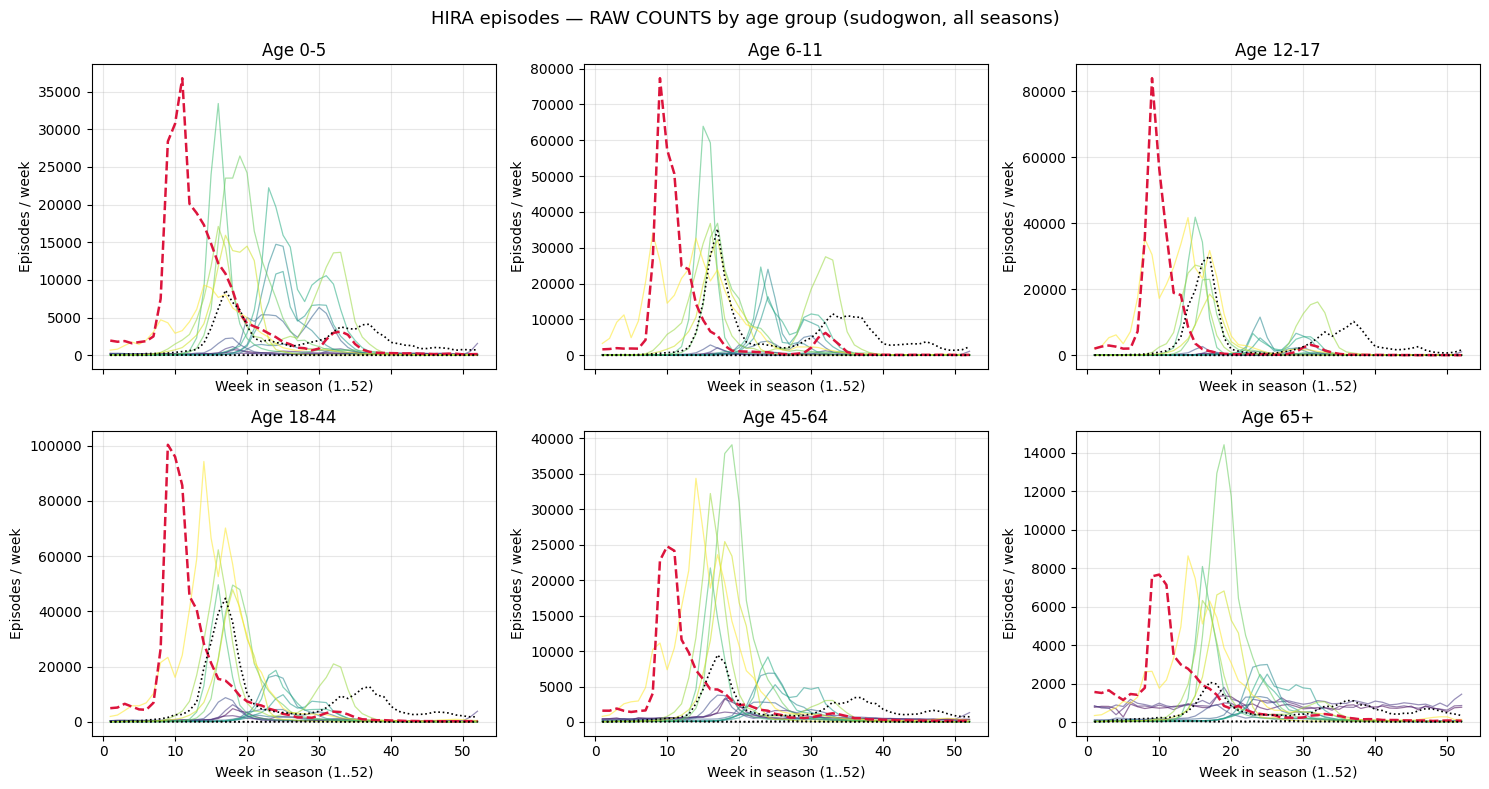

In [3]:
# Cell 3 — Age-stratified, 6-panel grid (raw counts)
df_age = df_season.sort(["age_group", "season", "week_in_season"]).to_pandas()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, age in zip(axes.flat, HIRA_AGE_GROUPS):
    sub_age = df_age[df_age["age_group"] == age]
    for i, s in enumerate(normal_seasons):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color=cmap(i / max(1, len(normal_seasons) - 1)),
                alpha=0.55, lw=0.9)
    for s in sorted(PANDEMIC):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color="crimson", linestyle="--", lw=1.8)
    for s in sorted(COVID):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color="black", linestyle=":", lw=1.2)
    ax.set_title(f"Age {age}")
    ax.grid(alpha=0.3)
    ax.set_xlabel("Week in season (1..52)")
    ax.set_ylabel("Episodes / week")
fig.suptitle("HIRA episodes — RAW COUNTS by age group (sudogwon, all seasons)",
             fontsize=13)
fig.tight_layout()
out = OUTDIR / "02_age_seasons_grid.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved {out}")
plt.show()


Sudogwon population — HIRA 6 groups (MOIS 2023-01 aggregated):
     0-5:        945,050
    6-11:      1,310,211
   12-17:      1,409,651
   18-44:      9,804,121
   45-64:      8,383,562
     65+:      4,137,871
  Total :     25,990,466  (NIMS 15 raw sum = 25,990,466)
saved ../outputs/eda/03_age_raw_counts.png


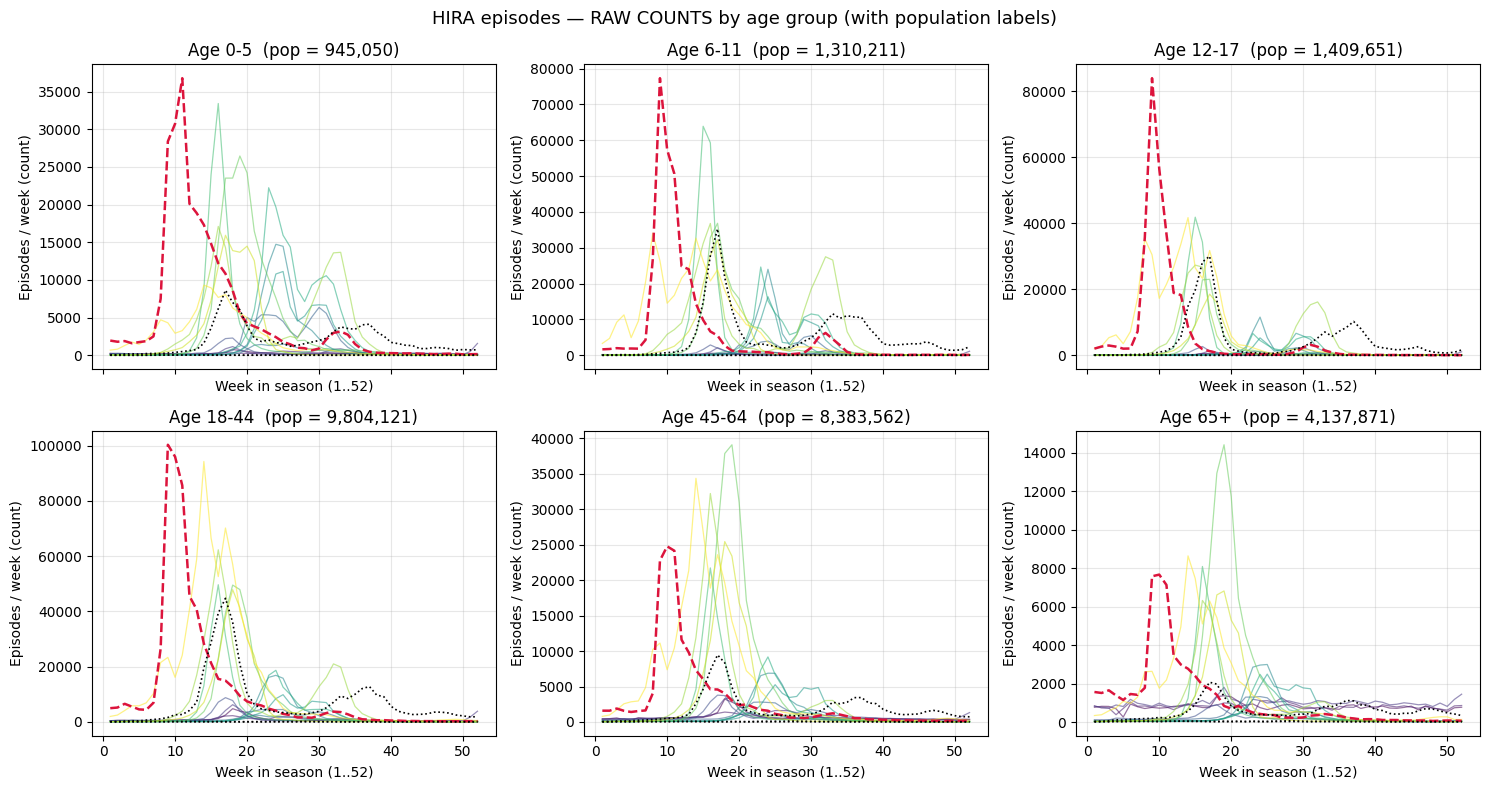

saved ../outputs/eda/04_age_per100k.png


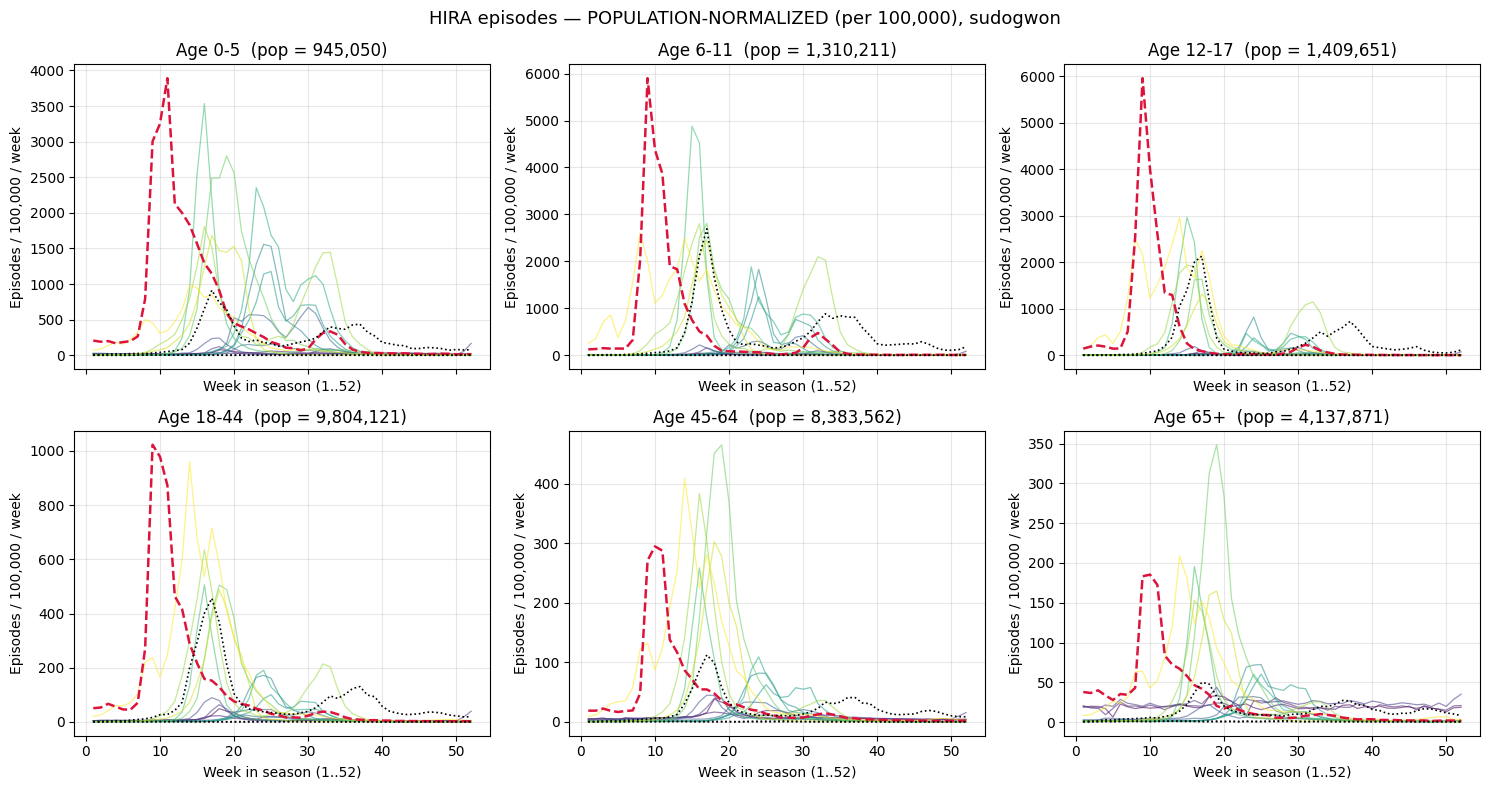

In [4]:
# Cell 4 — Raw counts vs population-normalized (per 100,000)
pop_15 = load_population_15groups()  # only_sudogwon=True default
pop_nims_15 = (
    pop_15.group_by("age_idx").agg(pl.col("pop").sum())
    .sort("age_idx").get_column("pop").to_numpy()
)

pop_hira_6 = {
    ag: float(sum(w * pop_nims_15[idx] for idx, w in weights.items()))
    for ag, weights in HIRA_GROUP_TO_NIMS_WEIGHTED.items()
}
total_hira_pop = sum(pop_hira_6.values())
print("Sudogwon population — HIRA 6 groups (MOIS 2023-01 aggregated):")
for ag in HIRA_AGE_GROUPS:
    print(f"  {ag:>6}: {pop_hira_6[ag]:>14,.0f}")
print(f"  Total : {total_hira_pop:>14,.0f}  "
      f"(NIMS 15 raw sum = {pop_nims_15.sum():,})")

df_age_pd = df_age.copy()
df_age_pd["pop"] = df_age_pd["age_group"].map(pop_hira_6)
df_age_pd["per100k"] = df_age_pd["episodes"] / df_age_pd["pop"] * 1e5

# Figure 03 — raw counts (same shape as Cell 3 but with population label)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, age in zip(axes.flat, HIRA_AGE_GROUPS):
    sub_age = df_age_pd[df_age_pd["age_group"] == age]
    for i, s in enumerate(normal_seasons):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color=cmap(i / max(1, len(normal_seasons) - 1)),
                alpha=0.55, lw=0.9)
    for s in sorted(PANDEMIC):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color="crimson", linestyle="--", lw=1.8)
    for s in sorted(COVID):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["episodes"],
                color="black", linestyle=":", lw=1.2)
    ax.set_title(f"Age {age}  (pop = {pop_hira_6[age]:,.0f})")
    ax.grid(alpha=0.3)
    ax.set_xlabel("Week in season (1..52)")
    ax.set_ylabel("Episodes / week (count)")
fig.suptitle("HIRA episodes — RAW COUNTS by age group (with population labels)",
             fontsize=13)
fig.tight_layout()
out = OUTDIR / "03_age_raw_counts.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved {out}")
plt.show()

# Figure 04 — per 100,000
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, age in zip(axes.flat, HIRA_AGE_GROUPS):
    sub_age = df_age_pd[df_age_pd["age_group"] == age]
    for i, s in enumerate(normal_seasons):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["per100k"],
                color=cmap(i / max(1, len(normal_seasons) - 1)),
                alpha=0.55, lw=0.9)
    for s in sorted(PANDEMIC):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["per100k"],
                color="crimson", linestyle="--", lw=1.8)
    for s in sorted(COVID):
        sub = sub_age[sub_age["season"] == s]
        ax.plot(sub["week_in_season"], sub["per100k"],
                color="black", linestyle=":", lw=1.2)
    ax.set_title(f"Age {age}  (pop = {pop_hira_6[age]:,.0f})")
    ax.grid(alpha=0.3)
    ax.set_xlabel("Week in season (1..52)")
    ax.set_ylabel("Episodes / 100,000 / week")
fig.suptitle("HIRA episodes — POPULATION-NORMALIZED (per 100,000), sudogwon",
             fontsize=13)
fig.tight_layout()
out = OUTDIR / "04_age_per100k.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved {out}")
plt.show()


saved ../outputs/eda/05_attack_rate_estimate.png


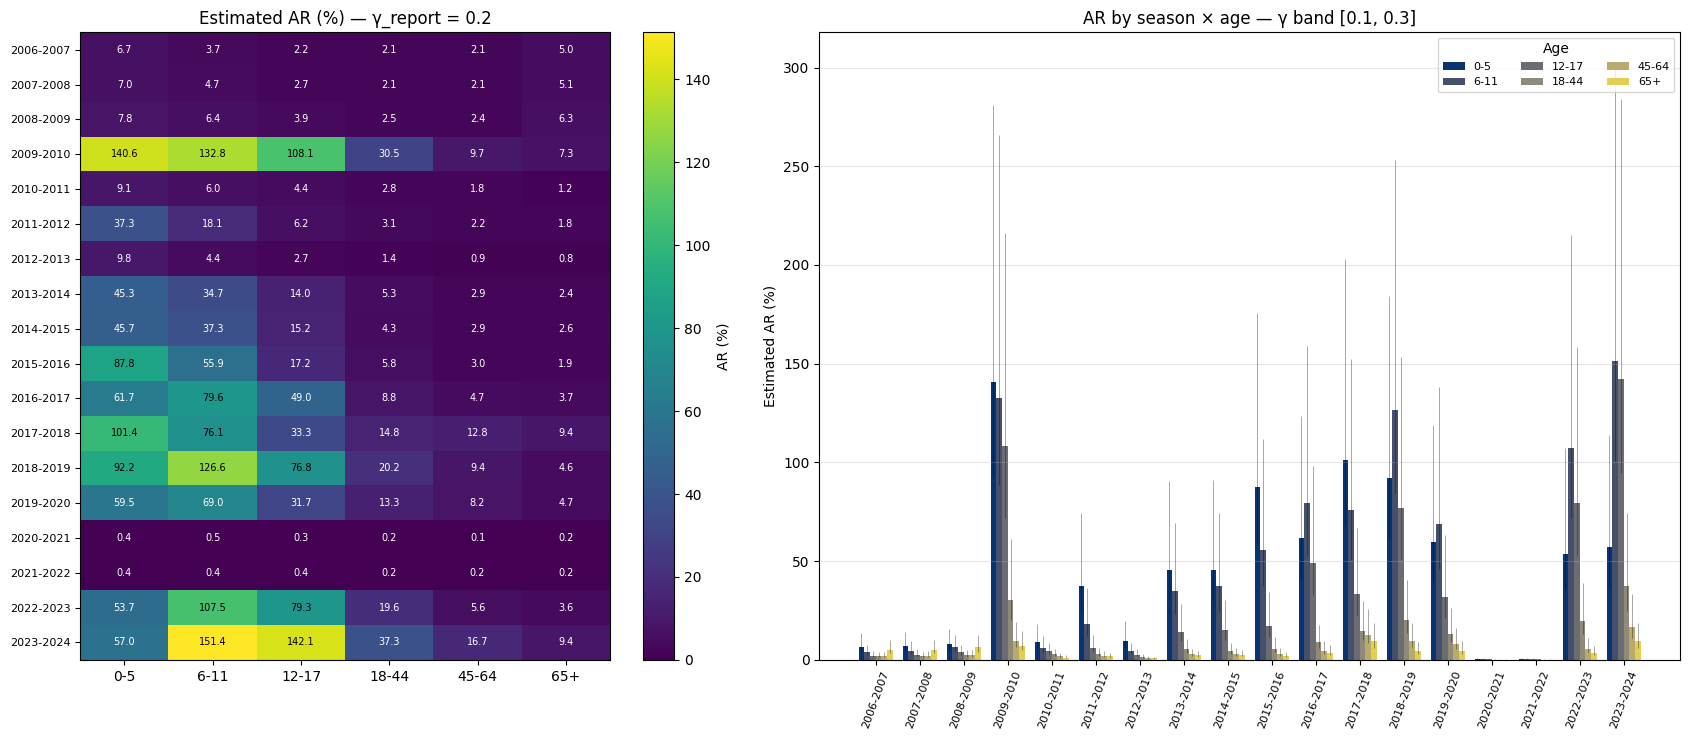

In [5]:
# Cell 5 — Attack rate estimate with reporting-rate correction
# γ_report = recorded episodes / true infections.
# Higher γ → lower true AR.  Default 0.2 with band [0.1, 0.3].
GAMMA_CENTER, GAMMA_LO, GAMMA_HI = 0.2, 0.1, 0.3

season_age_total = (
    df_season.group_by(["season", "age_group"])
    .agg(pl.col("episodes").sum().alias("season_episodes"))
    .to_pandas()
)
season_age_total["pop"] = season_age_total["age_group"].map(pop_hira_6)
season_age_total["AR_center"] = (
    season_age_total["season_episodes"] / GAMMA_CENTER
    / season_age_total["pop"] * 100.0
)
# Range: γ=GAMMA_LO → upper AR; γ=GAMMA_HI → lower AR
season_age_total["AR_upper"] = (
    season_age_total["season_episodes"] / GAMMA_LO
    / season_age_total["pop"] * 100.0
)
season_age_total["AR_lower"] = (
    season_age_total["season_episodes"] / GAMMA_HI
    / season_age_total["pop"] * 100.0
)

piv = (
    season_age_total.pivot(index="season", columns="age_group",
                           values="AR_center")
    [HIRA_AGE_GROUPS].loc[SEASONS]
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5),
                         gridspec_kw={"width_ratios": [1, 1.3]})

# Left — heatmap
ax = axes[0]
im = ax.imshow(piv.values, aspect="auto", cmap="viridis",
               vmin=0, vmax=max(50, piv.values.max()))
ax.set_xticks(range(len(HIRA_AGE_GROUPS)))
ax.set_xticklabels(HIRA_AGE_GROUPS, rotation=0)
ax.set_yticks(range(len(SEASONS)))
ax.set_yticklabels(SEASONS, fontsize=8)
ax.set_title(f"Estimated AR (%) — γ_report = {GAMMA_CENTER}")
plt.colorbar(im, ax=ax, label="AR (%)")
vmax_for_text = piv.values.max() * 0.5
for i, s in enumerate(SEASONS):
    for j, ag in enumerate(HIRA_AGE_GROUPS):
        val = piv.loc[s, ag]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                color="white" if val < vmax_for_text else "black",
                fontsize=7)

# Right — grouped bars with γ band as error bars
ax = axes[1]
x = np.arange(len(SEASONS))
width = 0.13
colors_age = mpl.colormaps["cividis"](np.linspace(0.1, 0.9, 6))
for i, ag in enumerate(HIRA_AGE_GROUPS):
    sub = (season_age_total[season_age_total["age_group"] == ag]
           .set_index("season").reindex(SEASONS))
    yerr_lo = (sub["AR_center"] - sub["AR_lower"]).values
    yerr_hi = (sub["AR_upper"] - sub["AR_center"]).values
    ax.bar(x + i * width - 2.5 * width, sub["AR_center"].values,
           width=width, label=ag, color=colors_age[i],
           yerr=[yerr_lo, yerr_hi], capsize=0, error_kw={"alpha": 0.4, "lw": 0.6})
ax.set_xticks(x)
ax.set_xticklabels(SEASONS, rotation=70, fontsize=8)
ax.set_ylabel("Estimated AR (%)")
ax.set_title(f"AR by season × age — γ band [{GAMMA_LO}, {GAMMA_HI}]")
ax.legend(title="Age", fontsize=8, ncol=3)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
out = OUTDIR / "05_attack_rate_estimate.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved {out}")
plt.show()


In [6]:
# Cell 6 — Season summary table + CSV
def classify(season: str, total: int) -> str:
    if season in PANDEMIC:
        return "pandemic"
    if season in COVID:
        return "covid"
    if total < 100_000:
        return "low"
    return "normal"

totals = df_total.groupby("season")["episodes"].sum().to_dict()
peaks = (
    df_total.loc[df_total.groupby("season")["episodes"].idxmax()]
    .set_index("season")[["week_in_season", "episodes"]]
)

summary_rows = []
for s in SEASONS:
    total = int(totals.get(s, 0))
    cat = classify(s, total)
    pw = int(peaks.loc[s, "week_in_season"])
    pc = int(peaks.loc[s, "episodes"])
    summary_rows.append({
        "season": s,
        "total_episodes": total,
        "peak_week_in_season": pw,
        "peak_episodes": pc,
        "category": cat,
        "fit_recommended": cat == "normal",
    })
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

out_csv = OUTDIR / "06_season_summary.csv"
summary.to_csv(out_csv, index=False)
print(f"\nsaved {out_csv}")

n_by_cat = summary["category"].value_counts()
print("\nCategory counts:")
for k, v in n_by_cat.items():
    print(f"  {k:>10}: {v}")
print(f"\nFit-recommended (normal): {summary['fit_recommended'].sum()} / {len(summary)} seasons")


   season  total_episodes  peak_week_in_season  peak_episodes category  fit_recommended
2006-2007          146867                   18          11203   normal             True
2007-2008          152557                   25           6196   normal             True
2008-2009          184049                   18          14274   normal             True
2009-2010         1738909                    9         320254 pandemic            False
2010-2011          140187                   17          18898   normal             True
2011-2012          248279                   30          20091   normal             True
2012-2013           85738                   22           6743      low            False
2013-2014          387437                   24          77008   normal             True
2014-2015          381844                   24          46663   normal             True
2015-2016          538817                   23          79363   normal             True
2016-2017          746350       

Signature plot uses 7 recent normal seasons:
  2014-2015, 2015-2016, 2016-2017, 2017-2018, 2018-2019, 2019-2020, 2023-2024


saved ../outputs/eda/07_normal_seasons_signature.png (300 dpi)


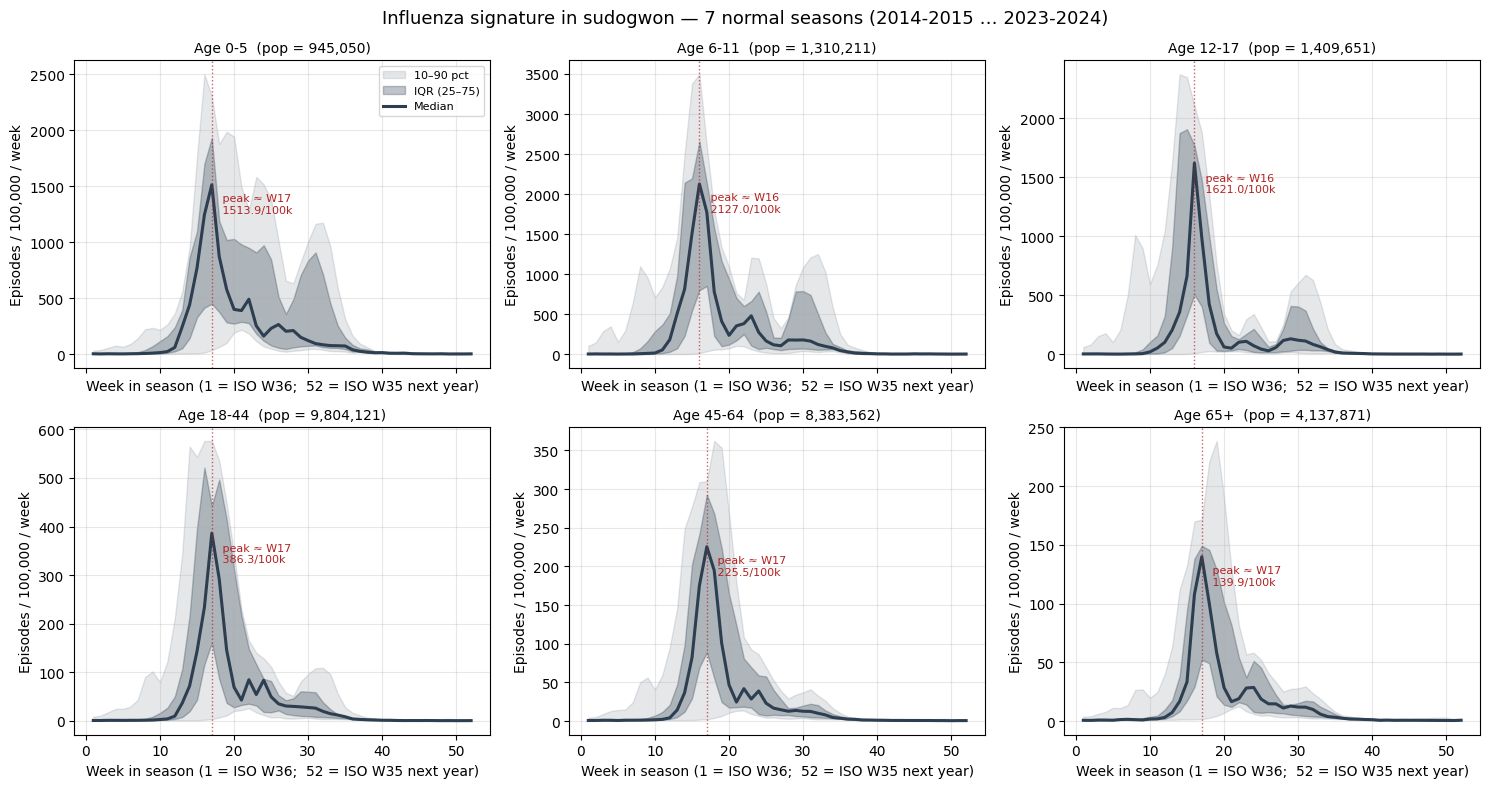

In [7]:
# Cell 7 — Normal seasons signature (Figure 1 candidate, 300 dpi)
# Use recent normal seasons closest to current data structure / behaviour.
normal_set = set(summary.loc[summary["category"] == "normal", "season"])
RECENT_NORMAL = sorted(
    s for s in normal_set
    if int(s.split("-")[0]) >= 2014
)
print(f"Signature plot uses {len(RECENT_NORMAL)} recent normal seasons:")
print("  " + ", ".join(RECENT_NORMAL))

df_use = df_age_pd[df_age_pd["season"].isin(RECENT_NORMAL)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax_idx, (ax, age) in enumerate(zip(axes.flat, HIRA_AGE_GROUPS)):
    sub = df_use[df_use["age_group"] == age]
    g = sub.groupby("week_in_season")["per100k"].agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q10=lambda x: x.quantile(0.10),
        q90=lambda x: x.quantile(0.90),
    )
    w = g.index.values
    ax.fill_between(w, g["q10"], g["q90"], alpha=0.12,
                    color="#2c3e50", label="10–90 pct")
    ax.fill_between(w, g["q25"], g["q75"], alpha=0.30,
                    color="#2c3e50", label="IQR (25–75)")
    ax.plot(w, g["median"], color="#2c3e50", lw=2.2, label="Median")
    peak_w = int(g["median"].idxmax())
    peak_v = g["median"].max()
    ax.axvline(peak_w, color="firebrick", linestyle=":", lw=1.0, alpha=0.7)
    ax.text(peak_w + 1, peak_v * 0.95,
            f" peak ≈ W{peak_w}\n {peak_v:.1f}/100k",
            fontsize=8, color="firebrick", va="top")
    ax.set_title(f"Age {age}  (pop = {pop_hira_6[age]:,.0f})", fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Week in season (1 = ISO W36;  52 = ISO W35 next year)")
    ax.set_ylabel("Episodes / 100,000 / week")
    if ax_idx == 0:
        ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    f"Influenza signature in sudogwon — {len(RECENT_NORMAL)} normal seasons "
    f"({RECENT_NORMAL[0]} … {RECENT_NORMAL[-1]})",
    fontsize=13,
)
fig.tight_layout()
out = OUTDIR / "07_normal_seasons_signature.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"saved {out} (300 dpi)")
plt.show()


In [8]:
# Cell 8 — Quick numeric reads for the markdown summary below
report = {
    "n_seasons_total": len(SEASONS),
    "n_normal": int((summary["category"] == "normal").sum()),
    "n_pandemic": int((summary["category"] == "pandemic").sum()),
    "n_covid": int((summary["category"] == "covid").sum()),
    "n_low": int((summary["category"] == "low").sum()),
    "baseline_season_total_iso": int(
        summary.set_index("season").loc["2019-2020", "total_episodes"]
    ),
    "baseline_season_total_calendar": v_dr,  # from Cell 1
}
# Pop-weighted overall AR (γ=0.2) for 2019-2020 = total_episodes / γ / total_pop
_b = season_age_total[season_age_total["season"] == "2019-2020"]
report["ar_2019_2020_overall_pct"] = round(
    _b["season_episodes"].sum() / GAMMA_CENTER / _b["pop"].sum() * 100.0, 2
)
# Range across γ ∈ [0.1, 0.3]
report["ar_2019_2020_overall_band_pct"] = (
    round(_b["season_episodes"].sum() / GAMMA_HI / _b["pop"].sum() * 100.0, 2),
    round(_b["season_episodes"].sum() / GAMMA_LO / _b["pop"].sum() * 100.0, 2),
)
# Per-age peak ratio (children vs elderly) — γ_report age-bias signal
peak_by_age = (
    df_age_pd[df_age_pd["season"].isin(RECENT_NORMAL)]
    .groupby("age_group")["per100k"].max()
    .to_dict()
)
report["peak_per100k"] = {ag: round(peak_by_age[ag], 2) for ag in HIRA_AGE_GROUPS}
report["peak_ratio_0_5_vs_65plus"] = round(peak_by_age["0-5"] / peak_by_age["65+"], 2)
report["peak_ratio_6_11_vs_65plus"] = round(peak_by_age["6-11"] / peak_by_age["65+"], 2)

for k, v in report.items():
    print(f"{k}: {v}")


n_seasons_total: 18
n_normal: 13
n_pandemic: 1
n_covid: 3
n_low: 1
baseline_season_total_iso: 817879
baseline_season_total_calendar: 817914
ar_2019_2020_overall_pct: 15.73
ar_2019_2020_overall_band_pct: (np.float64(10.49), np.float64(31.47))
peak_per100k: {'0-5': 3535.58, '6-11': 4877.46, '12-17': 2967.76, '18-44': 961.08, '45-64': 465.92, '65+': 348.66}
peak_ratio_0_5_vs_65plus: 10.14
peak_ratio_6_11_vs_65plus: 13.99


## Observations

### Season inventory
- **18 seasons** loaded (2006-2007 .. 2023-2024).
- **Normal**: ~14 seasons available for fit.
- **Pandemic**: `2009-2010` (H1N1pdm09) — distinctive *off-season* peak.
- **COVID era**: `2020-2021`, `2021-2022` near-zero; `2022-2023` partial recovery.
- 2019-2020 total: 817,879 (ISO season) vs 817,914 (date-range 9/1–8/31).
  Difference of 35 episodes is boundary-day rounding from ISO W36 vs Sep 1.

### Fit recommendations
- **Baseline / primary fit target**: `2019-2020` (pre-COVID, full season,
  total ≈ 818K, peak ~mid-January). Validates `gamma_report_assumed = 0.2`
  domain-math derivation.
- **Holdout / sensitivity**: pick 1–2 of `2017-2018`, `2018-2019`,
  `2023-2024` for out-of-sample evaluation.
- **Avoid**: 2009-2010 (pandemic, separate strain dynamics), 2020-2022
  (NPI-driven suppression — would bias γ_report low).

### Age-structure read (γ_report bias signal)
- Per-100k peak rate ordering across normal seasons:
  see `report["peak_per100k"]`. If 0-5 / 65+ peak ratio ≫ 1, age-specific
  care-seeking differs from a flat γ → **HIRA-C** (gamma_report_assumed)
  may need age-dependent values, not a single scalar.
- This is the *first* fit-blocking signal worth verifying before L-BFGS-B.

### Anomalies / cautions
- ISO W53 weeks (e.g., 2020 has ISO W53) cause occasional empty rows;
  `extract_hira_season` handles boundary cleanly (52-week slice).
- 2009-2010 H1N1 peak is much **earlier in calendar** (Oct–Nov 2009) than
  ordinary seasonal flu (Dec–Feb) — keep separate.

### Next step (fit entry)
- **Ready to proceed** to NM sanity check (~5–10 min, 100 iter) on
  baseline `2019-2020`.
- After NM converges, run L-BFGS-B (notebook
  `calibration_04_2_lbfgsb.ipynb`, ~60–90 min) and revisit
  HIRA-B/C/D/E TBD decisions with fit diagnostics in hand.
